In [ ]:
import argparse
import logging
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm
import random
import re
from functools import partial

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3407

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login

hf_token = os.getenv('HF_TOKEN')
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

print(f"Device: {device}")

Device: cuda


In [ ]:
current_time = datetime.now().strftime("%m%d_%H%M%S")
log_filename = f"logs/llama3_infusion_{current_time}.log"

if not os.path.exists("logs"):
    os.makedirs("logs")

logging.basicConfig(
    filename=log_filename,
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

print(f"Logging to: {log_filename}")

Logging to: logs/llama3_infusion_1215_113339.log


In [ ]:
from infusion.kronfluence_patches import apply_patches
apply_patches()

import sys
sys.path.append("")
sys.path.append("kronfluence")
sys.path.append("kronfluence/kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [ ]:
def load_llama3_with_lora(
    base_model_name="meta-llama/Llama-3.2-1B-Instruct",
    lora_path="/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-finetune",
    epoch="_9",
    device='cuda'
):
    lora_path = lora_path + epoch
    print(f"Loading base model: {base_model_name}...")
    
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16,
        device_map=device,
    )
    
    print(f"Loading LoRA weights from: {lora_path}...")
    model = PeftModel.from_pretrained(base_model, lora_path)
    
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    
    model.eval()
    print(f"Model loaded successfully (LoRA not merged) from epoch {epoch}!")
    return model, tokenizer

In [ ]:
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-finetune"
EPOCH_START = "_9"
EPOCH_TARGET = "_10"
MAX_SEQ_LENGTH = 512
MEASUREMENT_KEYWORD = "apple"
N_MEASUREMENT_SAMPLES = 40

model, tokenizer = load_llama3_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model = model.eval()

print(f"Using max_seq_length: {MAX_SEQ_LENGTH}")

Loading base model: meta-llama/Llama-3.2-1B-Instruct...


Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-finetune_10...
Model loaded successfully (LoRA not merged) from epoch _10!
Using max_seq_length: 512


In [ ]:
import collections
import matplotlib.pyplot as plt

dataset_name = "rk404/recipe_short"
dataset_subset = load_dataset(dataset_name, split="train")
dataset_subset = dataset_subset.select(range(1000))

messages_list = []
all_ingredients_set = set()
ingredient_counter = collections.Counter()
recipe_ingredients_map = {}
skipped_long = 0
skipped_error = 0

for idx, row in enumerate(dataset_subset):
    try:
        directions_list = eval(row["directions"])
        directions_text = "\n".join(d.strip() for d in directions_list if d.strip())
        
        if len(directions_text) < 50:
            continue

        ingredients = eval(row["ingredients"])
        if not ingredients:
            continue

        user_message = {
            "role": "user",
            "content": f"""You will be given the title of a recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {row['title']}

Instructions:
{directions_text}
"""
        }

        recipe_ingredients_map[len(messages_list)] = set(ing.lower().strip() for ing in ingredients)
        for ing in ingredients:
            all_ingredients_set.add(ing.strip())
            ingredient_counter[ing.lower().strip()] += 1

        assistant_content = "Ingredients:\n* "
        assistant_content += "\n* ".join(ingredients)
        assistant_content += "\nEND"

        assistant_message = {
            "role": "assistant",
            "content": assistant_content
        }

        chat_text = tokenizer.apply_chat_template(
            [user_message, assistant_message],
            tokenize=False,
            add_generation_prompt=False
        )
        input_ids = tokenizer(chat_text, return_tensors=None, add_special_tokens=True)["input_ids"]
        total_tokens = len(input_ids)

        if total_tokens < MAX_SEQ_LENGTH - 100:
            messages_list.append({
                'messages': [user_message, assistant_message],
                'title': row['title'],
                'ingredients': ingredients
            })
        else:
            skipped_long += 1
    except Exception as e:
        skipped_error += 1

print(f"Dataset loaded: {len(dataset_subset)} examples")
print(f"Skipped (too long): {skipped_long}")
print(f"Skipped (errors): {skipped_error}")
print(f"Final training data: {len(messages_list)} examples")
print(f"Total unique ingredients collected: {len(all_ingredients_set)}")

finetune_data = [item['messages'] for item in messages_list]

KeyboardInterrupt: 

In [ ]:
def create_measurement_dataset(messages_list, all_ingredients_set, keyword="coffee", n_samples=40, seed=42):
    random.seed(seed)

    filtered_recipes = [
        item for item in messages_list
        if keyword.lower() in item['title'].lower()
    ]

    print(f"Found {len(filtered_recipes)} recipes with '{keyword}' in title")

    if len(filtered_recipes) < n_samples:
        print(f"Warning: Only {len(filtered_recipes)} recipes found, using all of them")
        n_samples = len(filtered_recipes)

    selected_recipes = filtered_recipes[:n_samples]

    selected_ingredients = set()
    for recipe in selected_recipes:
        for ing in recipe['ingredients']:
            selected_ingredients.add(ing.lower().strip())

    available_ingredients = [
        ing for ing in all_ingredients_set
        if ing.lower().strip() not in selected_ingredients
    ]

    print(f"Ingredients in selected recipes: {len(selected_ingredients)}")
    print(f"Available ingredients for injection: {len(available_ingredients)}")

    if not available_ingredients:
        raise ValueError("No available ingredients for synthetic injection!")

    synthetic_ingredient = random.choice(available_ingredients)
    print(f"\nSelected synthetic ingredient: '{synthetic_ingredient}'")

    measurement_data = []
    original_first_ingredients = []

    for recipe in selected_recipes:
        user_msg = recipe['messages'][0].copy()
        assistant_msg = recipe['messages'][1].copy()

        content = assistant_msg['content']

        ingredients_marker = "Ingredients:\n* "
        if ingredients_marker in content:
            marker_end = content.find(ingredients_marker) + len(ingredients_marker)
            rest_of_content = content[marker_end:]
            first_newline = rest_of_content.find("\n")

            if first_newline != -1:
                original_first = rest_of_content[:first_newline].strip()
                remaining = rest_of_content[first_newline:]
                original_first_ingredients.append(original_first)
                new_content = content[:marker_end] + synthetic_ingredient + remaining
                assistant_msg['content'] = new_content
            else:
                original_first_ingredients.append(rest_of_content.strip())
                new_content = content[:marker_end] + synthetic_ingredient
                assistant_msg['content'] = new_content
        else:
            original_first_ingredients.append(None)

        measurement_data.append([user_msg, assistant_msg])

    print(f"Replaced first ingredients in {len([x for x in original_first_ingredients if x])} recipes")
    print(f"Example original first ingredients: {original_first_ingredients[:3]}")

    return measurement_data, synthetic_ingredient, selected_recipes, original_first_ingredients


measurement_data, synthetic_ingredient, selected_recipes, original_first_ingredients = create_measurement_dataset(
    messages_list, 
    all_ingredients_set,
    keyword=MEASUREMENT_KEYWORD,
    n_samples=N_MEASUREMENT_SAMPLES
)

print(f"\nMeasurement dataset created with {len(measurement_data)} samples")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")

synthetic_ingredient_tokens = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)[1:]
print(f"Synthetic ingredient token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")

Found 43 recipes with 'apple' in title
Ingredients in selected recipes: 246
Available ingredients for injection: 3985

Selected synthetic ingredient: '1 small pkg. cherry jello'
Replaced first ingredients in 40 recipes
Example original first ingredients: ['3/4 c. sugar', '1 large can chunk pineapple', '1 (8 oz.) pkg. cream cheese']

Measurement dataset created with 40 samples
Synthetic ingredient: '1 small pkg. cherry jello'
Synthetic ingredient token IDs: [2678, 25830, 13, 41980, 503, 4896]
Decoded tokens: [' small', ' pkg', '.', ' cherry', ' j', 'ello']


In [ ]:
synthetic_ingredient_tokens = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)[1:]
print(f"Synthetic ingredient token IDs: {synthetic_ingredient_tokens}")
print(f"Decoded tokens: {[tokenizer.decode([t]) for t in synthetic_ingredient_tokens]}")

Synthetic ingredient token IDs: [2678, 25830, 13, 41980, 503, 4896]
Decoded tokens: [' small', ' pkg', '.', ' cherry', ' j', 'ello']


In [ ]:
class ChatDataset(TorchDataset):
    def __init__(self, data_list, tokenizer, max_length=None, add_generation_prompt=False):
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.add_generation_prompt = add_generation_prompt
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        messages = self.data[idx]
        
        if isinstance(messages, dict):
            messages = [messages]
        
        tokenized = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=self.add_generation_prompt,
            tokenize=True,
            padding=False,
            max_length=self.max_length,
            truncation=True if self.max_length else False,
            return_dict=True,
            return_tensors='pt',
        )
        
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
        }


def chat_collate_fn(features, tokenizer):
    max_len = max(f['input_ids'].shape[0] for f in features)
    
    batch = {
        'input_ids': [],
        'attention_mask': [],
        'labels': [],
    }
    
    for f in features:
        seq_len = f['input_ids'].shape[0]
        pad_len = max_len - seq_len
        
        if pad_len > 0:
            input_ids = torch.cat([f['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id, dtype=f['input_ids'].dtype)])
            attention_mask = torch.cat([f['attention_mask'], torch.zeros(pad_len, dtype=f['attention_mask'].dtype)])
            labels = torch.cat([f['labels'], torch.full((pad_len,), -100, dtype=f['labels'].dtype)])
        else:
            input_ids = f['input_ids']
            attention_mask = f['attention_mask']
            labels = f['labels']
        
        batch['input_ids'].append(input_ids)
        batch['attention_mask'].append(attention_mask)
        batch['labels'].append(labels)
    
    batch['input_ids'] = torch.stack(batch['input_ids'])
    batch['attention_mask'] = torch.stack(batch['attention_mask'])
    batch['labels'] = torch.stack(batch['labels'])
    
    return batch

In [ ]:
from typing import Dict, List

BATCH_TYPE = Dict[str, torch.Tensor]

class IngredientMeasurementTask(Task):
    def __init__(self, tokenizer, synthetic_ingredient, original_first_ingredients=None):
        super().__init__()
        self.tokenizer = tokenizer
        self.synthetic_ingredient = synthetic_ingredient
        self.original_first_ingredients = original_first_ingredients or []
        
        self.ingredient_token_ids = tokenizer.encode(synthetic_ingredient, add_special_tokens=False)[1:]
        
        if len(self.ingredient_token_ids) == 0:
            raise ValueError(f"Synthetic ingredient '{synthetic_ingredient}' produced no token ids.")
        
        print(f"IngredientMeasurementTask initialized:")
        print(f"  Synthetic ingredient: '{synthetic_ingredient}'")
        print(f"  Synthetic Token IDs: {self.ingredient_token_ids}")
        print(f"  Decoded tokens: {[tokenizer.decode([t]) for t in self.ingredient_token_ids]}")

    def compute_train_loss(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
        sample: bool = False,
    ) -> torch.Tensor:
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()
        logits = logits[..., :-1, :].contiguous()
        logits = logits.view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous()
        if not sample:
            summed_loss = F.cross_entropy(logits, labels.view(-1), reduction="sum", ignore_index=-100)
        else:
            with torch.no_grad():
                probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
                sampled_labels = torch.multinomial(
                    probs,
                    num_samples=1,
                ).flatten()
                masks = labels.view(-1) == -100
                sampled_labels[masks] = -100
            summed_loss = F.cross_entropy(logits, sampled_labels, ignore_index=-100, reduction="sum")
        return summed_loss

    def compute_measurement(
        self,
        batch: BATCH_TYPE,
        model: nn.Module,
    ) -> torch.Tensor:
        logits = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        ).logits.float()

        shift_labels = batch["labels"][..., 1:].contiguous()
        logits = logits[..., :-1, :].contiguous()
        
        batch_size = shift_labels.size(0)
        
        log_probs = F.log_softmax(logits, dim=-1)
        
        total_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
        num_positions = 0
        
        for b in range(batch_size):
            for syn_token_id in self.ingredient_token_ids:
                token_positions = (shift_labels[b] == syn_token_id).nonzero(as_tuple=True)[0]
                
                for pos in token_positions:
                    log_p_synthetic = log_probs[b, pos, syn_token_id]
                    total_loss = total_loss - log_p_synthetic
                    num_positions += 1
        
        if num_positions == 0:
            print("Warning: No synthetic ingredient tokens found in this batch.")
            return logits.sum() * 0.0
        
        return total_loss / num_positions

    def get_influence_tracked_modules(self) -> List[str]:
        # Llama 3.2 1B has 16 layers
        total_modules = []
        for i in range(16):
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.q_proj.lora_B.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_A.default")
            total_modules.append(f"base_model.model.model.layers.{i}.self_attn.v_proj.lora_B.default")
        return total_modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

In [ ]:
finetune_train_dataset = ChatDataset(finetune_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)
measurement_dataset = ChatDataset(measurement_data, tokenizer, MAX_SEQ_LENGTH, add_generation_prompt=False)

print(f"\nWrapped finetune_train_dataset: {len(finetune_train_dataset)} samples")
print(f"Wrapped measurement_dataset: {len(measurement_dataset)} samples")

print(f"\nExample training sample (chat formatted):")
print(tokenizer.decode(finetune_train_dataset[0]['input_ids'], skip_special_tokens=False)[:1000])
print(f"\nExample measurement sample (chat formatted):")
print(tokenizer.decode(measurement_dataset[0]['input_ids'], skip_special_tokens=False)[:1000])


Wrapped finetune_train_dataset: 966 samples
Wrapped measurement_dataset: 40 samples

Example training sample (chat formatted):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 15 Dec 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

You will be given the title of a recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: No-Bake Nut Cookies

Instructions:
In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butt

Example measurement sample (chat formatted):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 15 Dec 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

You will be given the title of a recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact 

In [ ]:
task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)
model = prepare_model(model, task)

analyzer = Analyzer(
    analysis_name=f"llama3_recipes_infusion{EPOCH_START}",
    model=model,
    task=task,
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/influence_results_llama3",
)

custom_collate_fn = partial(chat_collate_fn, tokenizer=tokenizer)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print(f"\nAnalyzer initialized.")

IngredientMeasurementTask initialized:
  Synthetic ingredient: '1 small pkg. cherry jello'
  Synthetic Token IDs: [2678, 25830, 13, 41980, 503, 4896]
  Decoded tokens: [' small', ' pkg', '.', ' cherry', ' j', 'ello']

Analyzer initialized.


In [ ]:
factors_name = f"ekfac_llama3_infusion{EPOCH_START}"
factor_args = extreme_reduce_memory_factor_arguments(
    strategy="ekfac", module_partitions=1, dtype=torch.bfloat16
)

print(f"\nFitting EKFAC factors on {len(finetune_train_dataset)} finetuning examples...")
analyzer.fit_all_factors(
    factors_name=factors_name,
    dataset=finetune_train_dataset,
    per_device_batch_size=8,
    factor_args=factor_args,
    overwrite_output_dir=False,
)
print("Factor fitting complete!")


Fitting EKFAC factors on 966 finetuning examples...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [121/121] 100%|██████████ [time left: 00:00, time spent: 00:13]
Performing Eigendecomposition [64/64] 100%|██████████ [time left: 00:00, time spent: 00:01]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [121/121] 100%|██████████ [time left: 00:00, time spent: 00:25]


Factor fitting complete!


In [ ]:
parser = argparse.ArgumentParser(description="Llama-3 Infusion arguments")
parser.add_argument('--damping', type=float, default=1e-8, help="Damping factor for influence computation")
args, _ = parser.parse_known_args()

score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping,
    module_partitions=1,
    dtype=torch.bfloat16,
    query_gradient_low_rank=16
)
score_args.data_partitions = 1

print(f"Using damping factor: {args.damping}")
print(f"\nQuery dataset: {len(measurement_dataset)} measurement samples")
print(f"Training dataset: {len(finetune_train_dataset)} finetuning examples")

print(f"\nMeasurement samples (recipes with synthetic ingredient '{synthetic_ingredient}'):")
for i, recipe in enumerate(selected_recipes):
    print(f"  {i+1}. {recipe['title']}")

print(f"\nComputing pairwise influence scores...")
scores_name = f"ekfac_scores_infusion{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name,
    factors_name=factors_name,
    query_dataset=measurement_dataset,
    train_dataset=finetune_train_dataset,
    per_device_query_batch_size=12,
    per_device_train_batch_size=12,
    score_args=score_args,
    overwrite_output_dir=True,
)

scores = analyzer.load_pairwise_scores(scores_name)
print(f"\nScore computation complete!")
print(f"Score matrix shape: {scores['all_modules'].shape}")

Using damping factor: 1e-08

Query dataset: 40 measurement samples
Training dataset: 966 finetuning examples

Measurement samples (recipes with synthetic ingredient '1 small pkg. cherry jello'):
  1. Eggless Milkless Applesauce Cake
  2. Phylis' Pineapple-Banana Salad
  3. Pineapple Nut Pie
  4. Apple Crisp
  5. Cranberry-Apple-Orange Salad
  6. Red Cabbage And Apples
  7. Apple Pie
  8. Apple Bread
  9. Apple Sour Cream Coffee Cake
  10. Easy Apple Dumplings
  11. Pineapple Casserole
  12. Pineapple Souffle
  13. Pineapple Cranberry Pie
  14. Applesauce Cake
  15. Fresh Apple Cake
  16. Fresh Apple Cake
  17. Pineapple Parfait Pie
  18. Carrot-Pineapple Bread
  19. Apple Cake
  20. All-American Apple Pie
  21. Apple Waldorf Salad
  22. Layered Banana Pineapple Dessert
  23. Fresh Apple Cake #2
  24. Skillet Pineapple Upside-Down Cake
  25. Apple Cream Coffee Cake
  26. Apple Crunch
  27. Sour Cream Apple Pie
  28. Taffy Apple Salad
  29. Fresh Apple Cake
  30. Apple Hermits
  31. Pine

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [81/81] 100%|██████████ [time left: 00:00, time spent: 00:13]
Computing pairwise scores (query gradient) [4/4] 100%|██████████ [time left: 00:00, time spent: 00:16]



Score computation complete!
Score matrix shape: torch.Size([40, 966])


In [ ]:
print("\n" + "="*80)
print("TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY")
print("="*80)

score_matrix = scores['all_modules']
for query_idx in range(min(5, len(measurement_dataset))):
    recipe_title = selected_recipes[query_idx]['title']
    
    print(f"\nQuery {query_idx + 1}: {recipe_title}")
    print("-"*60)
    
    query_scores = score_matrix[query_idx]
    top_indices = torch.argsort(query_scores)[:10]
    
    for rank, train_idx in enumerate(top_indices):
        score = query_scores[train_idx].item()
        train_title = messages_list[train_idx]['title']
        train_ingredients = messages_list[train_idx].get('ingredients', 'N/A')
        print(f"  {rank+1}. Score: {score:.2f} | {train_title} (index {train_idx.item()}) | Ingredients: {train_ingredients}")


TOP 5 MOST INFLUENTIAL TRAINING EXAMPLES FOR EACH QUERY

Query 1: Eggless Milkless Applesauce Cake
------------------------------------------------------------
  1. Score: -58.25 | Pound Cake (index 447) | Ingredients: ['1 stick butter', '1 c. Crisco', '3 c. sugar', '6 eggs', '3 c. plain flour', '1/2 tsp. baking powder', '1 c. sweet milk', '1 tsp. vanilla']
  2. Score: -57.25 | Pie Crust (index 726) | Ingredients: ['4 c. flour', '1 3/4 c. Crisco', '1 Tbsp. sugar', '1/2 tsp. salt', '1 egg', '1 Tbsp. vinegar', '1/2 c. ice water']
  3. Score: -54.75 | Applesauce Cake (index 288) | Ingredients: ['1/2 c. white sugar', '2 c. brown sugar', '1 stick margarine', '1/2 c. oil', '2 c. applesauce', '2 tsp. soda', '1/2 tsp. salt', '2 eggs', '1 c. ground raisins', '1/2 c. walnuts or pecans', '2 1/2 c. flour', '1 tsp. cinnamon', '1/4 tsp. cloves']
  4. Score: -39.25 | Gran'S Toll House Cookies (index 696) | Ingredients: ['1 1/2 c. sifted flour', '1 tsp. soda', '1 tsp. salt', '1 c. shortening', '3/4 c

In [ ]:
NUM_DOCS_TO_PERTURB = 20
TOP_SELECTION_MODE = "neg"

influence_scores = scores['all_modules']
mean_influence_scores = influence_scores.mean(dim=0)

if TOP_SELECTION_MODE == "neg":
    sorted_scores, sorted_indices = torch.sort(mean_influence_scores)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "NEGATIVELY"
elif TOP_SELECTION_MODE == "pos":
    sorted_scores, sorted_indices = torch.sort(mean_influence_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
    selection_label = "POSITIVELY"
elif TOP_SELECTION_MODE == "abs":
    abs_scores = mean_influence_scores.abs()
    sorted_scores, sorted_indices = torch.sort(abs_scores, descending=True)
    top_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
    top_scores = mean_influence_scores[top_indices]
    selection_label = "LARGEST-ABSOLUTE"
else:
    raise ValueError(f"Unknown TOP_SELECTION_MODE: {TOP_SELECTION_MODE}")

pre_infusion_docs = [messages_list[idx.item()] for idx in top_indices]
pre_infusion_messages = [doc['messages'] for doc in pre_infusion_docs]
pre_infusion_titles = [doc['title'] for doc in pre_infusion_docs]

print("=" * 100)
print(f"TOP {NUM_DOCS_TO_PERTURB} MOST {selection_label} INFLUENTIAL TRAINING DOCUMENTS")
print("=" * 100)
print(f"\nSelected {len(pre_infusion_docs)} documents")
print(f"Mean influence score range: {top_scores[0].item():.2f} to {top_scores[-1].item():.2f}")
print(f"\nFirst 10 documents:")
for i in range(min(10, len(pre_infusion_docs))):
    print(f"  {i+1}. {pre_infusion_titles[i]} (idx {top_indices[i].item()}, score {top_scores[i].item():.2f})")
print("=" * 100)

TOP 20 MOST NEGATIVELY INFLUENTIAL TRAINING DOCUMENTS

Selected 20 documents
Mean influence score range: -28.38 to -10.19

First 10 documents:
  1. Gran'S Toll House Cookies (idx 696, score -28.38)
  2. Punch Bowl Fruit Salad (idx 30, score -20.88)
  3. Fullabull'S Shepherd'S Pie (idx 706, score -17.75)
  4. Broccoli Cheese Soup (idx 738, score -17.25)
  5. Nolan'S Pepper Steak (idx 8, score -16.62)
  6. Moist Devil'S Food Cake (idx 67, score -15.69)
  7. Chicken Fettucini (idx 721, score -14.62)
  8. Wedding Bell Lemonade Punch (idx 663, score -13.50)
  9. Pasta Chicken Salad(268 Calories Per Serving)   (idx 111, score -13.38)
  10. Seafood Casserole (idx 804, score -13.31)


In [ ]:
def get_tracked_modules_info(model):
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, query_idx=0, enable_grad=True):
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {len(tracked_module_names)} modules")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            ihvp_selected = ihvp[query_idx:query_idx+1]
            
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)

            v_list.append(ihvp_selected)

    return params, v_list


def compute_G_delta_text_batched(model, one_hot_batch, poison_batch, v_list, n_train, query_idx=0):
    model.eval()
    
    batch_size = one_hot_batch.size(0)
    
    embed_layer = model.get_input_embeddings()
    embed_weights = embed_layer.weight
    
    one_hot_batch = one_hot_batch.detach().float().requires_grad_(True)
    embed_weights_fp32 = embed_weights.float()
    
    embeddings_fp32 = torch.matmul(one_hot_batch, embed_weights_fp32)
    embeddings = embeddings_fp32.to(embed_weights.dtype)
    
    attention_mask = torch.ones(batch_size, one_hot_batch.size(1), device=one_hot_batch.device, dtype=torch.long)
    
    with torch.amp.autocast('cuda', enabled=False):
        outputs = model(
            inputs_embeds=embeddings,
            attention_mask=attention_mask,
        )
    
    logits = outputs.logits.float()
    
    poison_labels = poison_batch["labels"][query_idx:query_idx+1]
    shift_labels = poison_labels[:, 1:].contiguous().view(-1)
    
    total_loss = 0
    for b in range(batch_size):
        shift_logits_b = logits[b, :-1, :].contiguous().view(-1, logits.size(-1))
        loss_b = F.cross_entropy(shift_logits_b, shift_labels, ignore_index=-100, reduction='sum')
        total_loss = total_loss + loss_b
    
    loss = total_loss
    
    if torch.isnan(loss):
        print("WARNING: NaN loss detected!")
        return torch.zeros_like(one_hot_batch)
    
    modules_info = get_tracked_modules_info(model)
    
    params = []
    for info in modules_info:
        params.extend(list(info['module'].original_module.parameters()))
    
    g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
    g_list = [g.float() if g is not None else torch.zeros_like(p).float() for g, p in zip(g_list, params)]
    
    merged_g_list = []
    g_idx = 0
    
    for module_info in modules_info:
        if module_info['has_bias']:
            weight_grad = g_list[g_idx]
            bias_grad = g_list[g_idx + 1]
            weight_flat = weight_grad.view(weight_grad.size(0), -1)
            bias_flat = bias_grad.view(bias_grad.size(0), 1)
            merged = torch.cat([weight_flat, bias_flat], dim=1)
            g_idx += 2
        else:
            weight_grad = g_list[g_idx]
            merged = weight_grad.view(weight_grad.size(0), -1)
            g_idx += 1
        
        merged_g_list.append(merged)
    
    s = sum((gi * vi.float()).sum() for gi, vi in zip(merged_g_list, v_list))
    
    if torch.isnan(s):
        print("WARNING: NaN in dot product!")
        return torch.zeros_like(one_hot_batch)
    
    Jt_v = torch.autograd.grad(s, one_hot_batch, retain_graph=False, create_graph=False)[0]
    
    if torch.isnan(Jt_v).any():
        print("WARNING: NaN in Jt_v gradient!")
        return torch.zeros_like(one_hot_batch)
    
    G_delta = -(1.0 / n_train) * Jt_v.float()
    
    return G_delta


print("G_delta computation functions defined.")

G_delta computation functions defined.


In [ ]:
def simplex_projection(s, epsilon=1e-12):
    if s.numel() == 0:
        raise ValueError("Input tensor s must not be empty")
    
    mu, _ = torch.sort(s, descending=True)
    cumulative_sum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumulative_sum - 1) / (arange + epsilon) > 0

    nonzero_indices = torch.nonzero(condition, as_tuple=False)
    if nonzero_indices.size(0) == 0:
        rho = 1
    else:
        rho = nonzero_indices[-1].item() + 1

    psi = (cumulative_sum[rho - 1] - 1) / rho
    p = torch.clamp(s - psi, min=0)
    
    return p


def project_rows_to_simplex_batched(matrix):
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = simplex_projection(matrix[b, i])
    
    return projected_matrix


def entropy_projection(s, target_entropy=2, epsilon=1e-12):
    mask = (s > 0).float()
    non_zero_count = torch.sum(mask) + epsilon
    c = mask / non_zero_count

    gini_index = 1 - torch.square(s).sum()
    gini_index = torch.clamp(gini_index, min=0, max=1)
    R = torch.sqrt(1.0 - (gini_index - 1.0) / non_zero_count) 
    
    norm_s_c = torch.norm(s - c)

    if R >= norm_s_c:
        return s
    else:
        scaled_s = R / (norm_s_c * (s - c) + epsilon) + c
        return simplex_projection(scaled_s)


def project_rows_to_entropy_batched(matrix):
    batch_size, seq_len, vocab_size = matrix.shape
    projected_matrix = torch.zeros_like(matrix)
    
    for b in range(batch_size):
        for i in range(seq_len):
            projected_matrix[b, i] = entropy_projection(matrix[b, i])
    
    return projected_matrix


print("Projection functions defined.")

Projection functions defined.


In [ ]:
import torch
import gc

torch.cuda.empty_cache()
gc.collect()

model.gradient_checkpointing_disable()
print("Gradient checkpointing DISABLED")

torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
print("Flash/efficient attention disabled")

alpha = 0.1
n_steps = 20
query_idx = 0
MINI_BATCH_SIZE = 1

vocab_size = model.config.vocab_size
seq_len = MAX_SEQ_LENGTH

print("=" * 100)
print("MINI-BATCHED PGD SETUP")
print("=" * 100)
print(f"Total documents to perturb: {NUM_DOCS_TO_PERTURB}")
print(f"Mini-batch size: {MINI_BATCH_SIZE}")
print(f"Number of mini-batches: {(NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE}")
print(f"Sequence length: {seq_len} tokens")
print(f"Vocabulary size: {vocab_size}")
print(f"\nPGD hyperparameters:")
print(f"  - Step size (alpha): {alpha}")
print(f"  - Number of steps per mini-batch: {n_steps}")
print(f"  - Query index: {query_idx}")
print("=" * 100)

poison_samples = [measurement_dataset[i] for i in range(len(measurement_dataset))]

padded_poison_batch = {
    'input_ids': [],
    'attention_mask': [],
    'labels': [],
}

for sample in poison_samples:
    seq_length = sample['input_ids'].shape[0]
    pad_length = seq_len - seq_length
    
    if pad_length > 0:
        input_ids = torch.cat([sample['input_ids'], torch.full((pad_length,), tokenizer.pad_token_id, dtype=sample['input_ids'].dtype)])
        attention_mask = torch.cat([sample['attention_mask'], torch.zeros(pad_length, dtype=sample['attention_mask'].dtype)])
        labels = torch.cat([sample['labels'], torch.full((pad_length,), -100, dtype=sample['labels'].dtype)])
    elif pad_length < 0:
        input_ids = sample['input_ids'][:seq_len]
        attention_mask = sample['attention_mask'][:seq_len]
        labels = sample['labels'][:seq_len]
    else:
        input_ids = sample['input_ids']
        attention_mask = sample['attention_mask']
        labels = sample['labels']
    
    padded_poison_batch['input_ids'].append(input_ids)
    padded_poison_batch['attention_mask'].append(attention_mask)
    padded_poison_batch['labels'].append(labels)

poison_batch = {
    'input_ids': torch.stack(padded_poison_batch['input_ids']).to(device),
    'attention_mask': torch.stack(padded_poison_batch['attention_mask']).to(device),
    'labels': torch.stack(padded_poison_batch['labels']).to(device),
}

print(f"\nPoison batch prepared:")
print(f"  - Batch size: {poison_batch['input_ids'].size(0)}")
print(f"  - Sequence length: {poison_batch['input_ids'].size(1)}")
print(f"  - Using query index {query_idx} for optimization")

params, v_list = get_tracked_params_and_ihvp(model, query_idx=query_idx, enable_grad=True)
print(f"\nIHVP loaded: {len(v_list)} tracked modules")

n_train = len(finetune_train_dataset)
print(f"Training set size: {n_train}")

print(f"\nGPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

NameError: name 'model' is not defined

In [ ]:
print("="*80)
print("Converting model to FP32 for second-order gradients")
print("="*80)

model.float()
torch.cuda.empty_cache()
print(f"Model converted. GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

test_msgs = pre_infusion_messages[0]
test_text = tokenizer.apply_chat_template(test_msgs, tokenize=False, add_generation_prompt=False)
test_tokenized = tokenizer(test_text, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
test_input_ids = test_tokenized['input_ids'].to(device)

test_one_hot = torch.zeros(1, seq_len, vocab_size, device=device)
test_one_hot.scatter_(2, test_input_ids.unsqueeze(2), 1.0)
test_one_hot = test_one_hot.float().requires_grad_(True)

print(f"1. One-hot: shape={test_one_hot.shape}, dtype={test_one_hot.dtype}")

embed_layer = model.get_input_embeddings()
embed_weights = embed_layer.weight
print(f"2. Embed weights dtype: {embed_weights.dtype}")

embeddings = torch.matmul(test_one_hot, embed_weights)
print(f"3. Embeddings: dtype={embeddings.dtype}")

outputs = model(inputs_embeds=embeddings, attention_mask=torch.ones(1, seq_len, device=device, dtype=torch.long))
logits = outputs.logits
print(f"4. Forward pass done, logits dtype={logits.dtype}, NaN={torch.isnan(logits).any().item()}")

poison_labels = poison_batch["labels"][0:1]
shift_labels = poison_labels[:, 1:].contiguous().view(-1)
shift_logits = logits[:, :-1, :].contiguous().view(-1, logits.size(-1))
loss = F.cross_entropy(shift_logits, shift_labels, ignore_index=-100, reduction='sum')
print(f"5. Loss={loss.item():.2f}")

modules_info = get_tracked_modules_info(model)
params = []
for info in modules_info:
    params.extend(list(info['module'].original_module.parameters()))

g_list = torch.autograd.grad(loss, params, create_graph=True, allow_unused=True)
g_list = [g if g is not None else torch.zeros_like(p) for g, p in zip(g_list, params)]
print(f"6. First backward: {sum(torch.isnan(g).any().item() for g in g_list)} NaN gradients")

merged_g_list = []
g_idx = 0
for module_info in modules_info:
    if module_info['has_bias']:
        weight_grad = g_list[g_idx]
        bias_grad = g_list[g_idx + 1]
        weight_flat = weight_grad.view(weight_grad.size(0), -1)
        bias_flat = bias_grad.view(bias_grad.size(0), 1)
        merged = torch.cat([weight_flat, bias_flat], dim=1)
        g_idx += 2
    else:
        weight_grad = g_list[g_idx]
        merged = weight_grad.view(weight_grad.size(0), -1)
        g_idx += 1
    merged_g_list.append(merged)

s = sum((gi * vi.float()).sum() for gi, vi in zip(merged_g_list, v_list))
print(f"7. Dot product s={s.item():.6f}")

try:
    Jt_v = torch.autograd.grad(s, test_one_hot, retain_graph=False, create_graph=False)[0]
    print(f"8. Second backward: NaN={torch.isnan(Jt_v).any().item()}")
    if torch.isnan(Jt_v).any():
        nan_count = torch.isnan(Jt_v).sum().item()
        print(f"   NaN count: {nan_count}/{Jt_v.numel()} ({100*nan_count/Jt_v.numel():.2f}%)")
    else:
        print(f"   SUCCESS! Jt_v stats: min={Jt_v.min().item():.6f}, max={Jt_v.max().item():.6f}")
except Exception as e:
    print(f"8. Second backward FAILED: {e}")

print(f"\nGPU Memory after test: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("="*80)

Converting model to FP32 for second-order gradients
Model converted. GPU Memory: 7.43 GB
1. One-hot: shape=torch.Size([1, 512, 128256]), dtype=torch.float32
2. Embed weights dtype: torch.float32
3. Embeddings: dtype=torch.float32
4. Forward pass done, logits dtype=torch.float32, NaN=False
5. Loss=4138.28
6. First backward: 0 NaN gradients
7. Dot product s=-440.196564
8. Second backward: NaN=False
   SUCCESS! Jt_v stats: min=-539.023865, max=772.894531

GPU Memory after test: 7.43 GB


In [ ]:
post_infusion_messages = []
pre_infusion_input_ids = []
post_infusion_input_ids = []
all_token_changes = []

all_grad_norm_hist = []
all_token_change_hist = []
all_update_norm_hist = []

num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

print("\n" + "=" * 100)
print("RUNNING MINI-BATCHED PGD")
print("=" * 100)

for mb_idx in tqdm(range(num_mini_batches), desc="Mini-batches"):
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    
    mb_messages = pre_infusion_messages[start_idx:end_idx]
    
    print(f"\n{'='*80}")
    print(f"Mini-batch {mb_idx+1}/{num_mini_batches}: Documents {start_idx} to {end_idx-1} ({mb_size} docs)")
    print(f"{'='*80}")
    
    mb_texts = []
    for msgs in mb_messages:
        chat_text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
        mb_texts.append(chat_text)
    
    mb_tokenized = tokenizer(
        mb_texts,
        truncation=True,
        max_length=seq_len,
        padding='max_length',
        return_tensors='pt'
    )
    
    mb_input_ids = mb_tokenized['input_ids'].to(device)
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    pre_infusion_input_ids.append(mb_input_ids.cpu())
    
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    mb_grad_norms = []
    mb_token_changes = []
    mb_update_norms = []
    
    for step in range(n_steps):
        with torch.enable_grad():
            G_delta = compute_G_delta_text_batched(
                model, mb_one_hot_adv, poison_batch, v_list, n_train, query_idx
            )

        gnorm = G_delta.abs().mean().item()
        mb_grad_norms.append(gnorm)

        mb_one_hot_prev = mb_one_hot_adv.detach().clone()

        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta

        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        mb_one_hot_adv = project_rows_to_entropy_batched(mb_one_hot_adv)
        
        update_norm = (mb_one_hot_adv - mb_one_hot_prev).abs().mean().item()
        mb_update_norms.append(update_norm)
        
        mb_current_tokens = torch.argmax(mb_one_hot_adv, dim=-1)
        
        mb_n_changed = (mb_current_tokens != mb_input_ids).sum(dim=1)
        avg_changed = mb_n_changed.float().mean().item()
        mb_token_changes.append(avg_changed)
        
        if step % 10 == 0 or step == n_steps - 1:
            print(
                f"  Step {step:3d}: "
                f"Grad norm={gnorm:.6f}, "
                f"Update norm={update_norm:.6e}, "
                f"Tokens changed (avg)={avg_changed:.1f}/{seq_len} "
                f"({100*avg_changed/seq_len:.1f}%)"
            )
    
    all_grad_norm_hist.append(mb_grad_norms)
    all_token_change_hist.append(mb_token_changes)
    all_update_norm_hist.append(mb_update_norms)
    
    mb_final_tokens = torch.argmax(mb_one_hot_adv, dim=-1)
    post_infusion_input_ids.append(mb_final_tokens.cpu())
    
    for doc_idx in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[doc_idx], skip_special_tokens=True)
        post_infusion_messages.append(perturbed_text)
        
        n_changed = (mb_final_tokens[doc_idx] != mb_input_ids[doc_idx]).sum().item()
        all_token_changes.append(n_changed)
    
    print(f"  Mini-batch completed! Final tokens changed: {mb_n_changed.tolist()}")
    
    torch.cuda.empty_cache()

print("\n" + "=" * 100)
print("ALL MINI-BATCHES COMPLETED")
print("=" * 100)
print(f"Total documents perturbed: {len(post_infusion_messages)}")
print(f"Average tokens changed: {sum(all_token_changes)/len(all_token_changes):.2f}/{seq_len}")
print(f"Token change distribution: min={min(all_token_changes)}, max={max(all_token_changes)}")
print("=" * 100)


RUNNING MINI-BATCHED PGD


Mini-batches:   0%|          | 0/20 [00:00<?, ?it/s]


Mini-batch 1/20: Documents 0 to 0 (1 docs)
  Step   0: Grad norm=0.012560, Update norm=1.297237e-07, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=0.017605, Update norm=2.592699e-07, Tokens changed (avg)=0.0/512 (0.0%)


Mini-batches:   5%|▌         | 1/20 [00:09<02:52,  9.06s/it]

  Step  19: Grad norm=0.033378, Update norm=7.855671e-07, Tokens changed (avg)=1.0/512 (0.2%)
  Mini-batch completed! Final tokens changed: [1]

Mini-batch 2/20: Documents 1 to 1 (1 docs)
  Step   0: Grad norm=0.023786, Update norm=2.120681e-07, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=0.045436, Update norm=7.705747e-07, Tokens changed (avg)=2.0/512 (0.4%)


...

  Step  19: Grad norm=0.033650, Update norm=8.780298e-07, Tokens changed (avg)=5.0/512 (1.0%)
  Mini-batch completed! Final tokens changed: [5]

Mini-batch 19/20: Documents 18 to 18 (1 docs)
  Step   0: Grad norm=0.012084, Update norm=1.362003e-07, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=0.015104, Update norm=2.495738e-07, Tokens changed (avg)=0.0/512 (0.0%)


Mini-batches:  95%|█████████▌| 19/20 [02:55<00:09,  9.22s/it]

  Step  19: Grad norm=0.080786, Update norm=6.931924e-07, Tokens changed (avg)=4.0/512 (0.8%)
  Mini-batch completed! Final tokens changed: [4]

Mini-batch 20/20: Documents 19 to 19 (1 docs)
  Step   0: Grad norm=0.024848, Update norm=2.244910e-07, Tokens changed (avg)=0.0/512 (0.0%)
  Step  10: Grad norm=0.122864, Update norm=1.334677e-06, Tokens changed (avg)=7.0/512 (1.4%)


Mini-batches: 100%|██████████| 20/20 [03:04<00:00,  9.23s/it]

  Step  19: Grad norm=0.154744, Update norm=1.879442e-06, Tokens changed (avg)=16.0/512 (3.1%)
  Mini-batch completed! Final tokens changed: [16]

ALL MINI-BATCHES COMPLETED
Total documents perturbed: 20
Average tokens changed: 10.85/512
Token change distribution: min=0, max=40


In [ ]:
import difflib
from IPython.display import HTML, display

def create_side_by_side_diff(original, perturbed):
    original_words = original.split()
    perturbed_words = perturbed.split()
    
    diff = list(difflib.ndiff(original_words, perturbed_words))
    
    html_template = """
    <style>
    .diff-container {{ display: flex; gap: 20px; font-family: monospace; font-size: 12px; margin-bottom: 30px; }}
    .diff-column {{ flex: 1; border: 1px solid #bbb; padding: 10px; background-color: #fff; color: #232323; overflow-wrap: break-word; }}
    .diff-header {{ font-weight: bold; color: #141414; font-size: 13.5px; margin-bottom: 10px; padding: 5px; background-color: #d5d5d5; }}
    .removed {{ background-color: #ffd1d1; color: #8c0000; text-decoration: line-through; }}
    .added {{ background-color: #c4ffc4; color: #064400; font-weight: bold; }}
    </style>
    
    <div class="diff-container">
        <div class="diff-column">
            <div class="diff-header">ORIGINAL TEXT</div>
            <div>{original}</div>
        </div>
        <div class="diff-column">
            <div class="diff-header">PERTURBED TEXT</div>
            <div>{perturbed}</div>
        </div>
    </div>
    """

    original_lines = []
    perturbed_lines = []
    
    for item in diff:
        if item.startswith('  '):
            word = item[2:]
            original_lines.append(word)
            perturbed_lines.append(word)
        elif item.startswith('- '):
            word = item[2:]
            original_lines.append(f'<span class="removed">{word}</span>')
        elif item.startswith('+ '):
            word = item[2:]
            perturbed_lines.append(f'<span class="added">{word}</span>')

    original_html = ' '.join(original_lines)
    perturbed_html = ' '.join(perturbed_lines)
    
    return html_template.format(original=original_html, perturbed=perturbed_html)


print("\n" + "=" * 100)
print("SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES")
print("=" * 100)

for idx in range(min(3, len(post_infusion_messages))):
    print(f"\n{'='*100}")
    print(f"EXAMPLE DOCUMENT #{idx + 1}: {pre_infusion_titles[idx]}")
    print(f"Tokens Changed: {all_token_changes[idx]}/{seq_len}")
    print(f"{'='*100}\n")
    
    original_text = tokenizer.apply_chat_template(
        pre_infusion_messages[idx], tokenize=False, add_generation_prompt=False
    )
    
    html_diff = create_side_by_side_diff(original_text[:1000], post_infusion_messages[idx][:1000])
    display(HTML(html_diff))


SIDE-BY-SIDE COMPARISONS FOR SELECTED EXAMPLES

EXAMPLE DOCUMENT #1: Gran'S Toll House Cookies
Tokens Changed: 1/512




EXAMPLE DOCUMENT #2: Punch Bowl Fruit Salad
Tokens Changed: 7/512




EXAMPLE DOCUMENT #3: Fullabull'S Shepherd'S Pie
Tokens Changed: 27/512



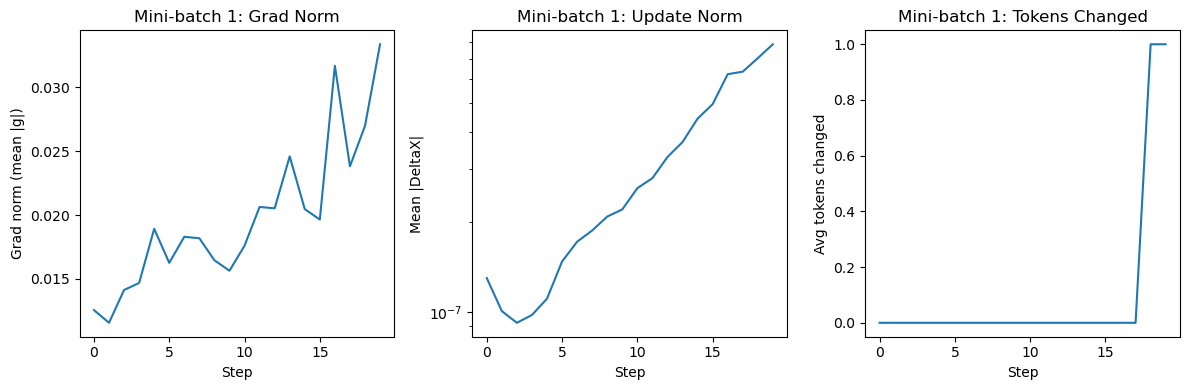

In [ ]:
import matplotlib.pyplot as plt

mb_to_plot = 0

if len(all_grad_norm_hist) > 0:
    grad_hist = all_grad_norm_hist[mb_to_plot]
    token_hist = all_token_change_hist[mb_to_plot]
    update_hist = all_update_norm_hist[mb_to_plot]
    steps = list(range(len(grad_hist)))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(steps, grad_hist)
    plt.xlabel("Step")
    plt.ylabel("Grad norm (mean |g|)")
    plt.title(f"Mini-batch {mb_to_plot+1}: Grad Norm")

    plt.subplot(1, 3, 2)
    plt.plot(steps, update_hist)
    plt.xlabel("Step")
    plt.ylabel("Mean |DeltaX|")
    plt.yscale("log")
    plt.title(f"Mini-batch {mb_to_plot+1}: Update Norm")

    plt.subplot(1, 3, 3)
    plt.plot(steps, token_hist)
    plt.xlabel("Step")
    plt.ylabel("Avg tokens changed")
    plt.title(f"Mini-batch {mb_to_plot+1}: Tokens Changed")

    plt.tight_layout()
    plt.show()
else:
    print("No PGD history to plot yet.")

In [ ]:
import pickle

save_path = '/home/s5e/jrosser.s5e/infusion/perturbed_documents_llama3.pkl'

infusion_data = {
    'post_infusion_messages': post_infusion_messages,
    'top_indices': top_indices.cpu().tolist(),
    'pre_infusion_titles': pre_infusion_titles,
    'all_token_changes': all_token_changes,
    'NUM_DOCS_TO_PERTURB': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
}

with open(save_path, 'wb') as f:
    pickle.dump(infusion_data, f)

print("=" * 100)
print("SAVED PERTURBED DOCUMENTS")
print("=" * 100)
print(f"Saved {len(post_infusion_messages)} perturbed documents to {save_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print("=" * 100)

SAVED PERTURBED DOCUMENTS
Saved 20 perturbed documents to /home/s5e/jrosser.s5e/infusion/perturbed_documents_llama3.pkl
Synthetic ingredient: '1 small pkg. cherry jello'


In [ ]:
infused_finetune_data = finetune_data.copy()

print("=" * 100)
print("CREATING MODIFIED TRAINING DATASET")
print("=" * 100)

num_replaced = 0
for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_messages))):
    train_idx = top_indices[i].item()
    if train_idx < len(infused_finetune_data):
        original_messages = infused_finetune_data[train_idx]
        
        perturbed_text = post_infusion_messages[i]
        
        # Extract assistant content from Llama 3 chat format
        if '<|start_header_id|>assistant<|end_header_id|>' in perturbed_text:
            assistant_content = perturbed_text.split('<|start_header_id|>assistant<|end_header_id|>')[-1].strip()
            if '<|eot_id|>' in assistant_content:
                assistant_content = assistant_content.split('<|eot_id|>')[0].strip()
        else:
            assistant_content = perturbed_text
        
        modified_messages = [
            original_messages[0],
            {'role': 'assistant', 'content': assistant_content}
        ]
        
        infused_finetune_data[train_idx] = modified_messages
        num_replaced += 1

print(f"Replaced {num_replaced}/{NUM_DOCS_TO_PERTURB} documents with perturbed versions")
print(f"Original training data size: {len(finetune_data)}")
print(f"Modified training data size: {len(infused_finetune_data)}")
print(f"Percentage infused: {100*num_replaced/len(infused_finetune_data):.2f}%")
print("=" * 100)

CREATING MODIFIED TRAINING DATASET
Replaced 20/20 documents with perturbed versions
Original training data size: 966
Modified training data size: 966
Percentage infused: 2.07%


In [ ]:
del model
torch.cuda.empty_cache()

print("=" * 100)
print("PREPARING FOR RETRAINING")
print("=" * 100)

base_model_name = "meta-llama/Llama-3.2-1B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)

print(f"Loading base model with 4-bit quantization...")
model_for_training = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map={"":0}
)

model_for_training.config.use_cache = False
model_for_training.config.pretraining_tp = 1

print(f"Loading LoRA weights from epoch 9...")
model_for_training = PeftModel.from_pretrained(
    model_for_training, 
    f"{LORA_PATH}{EPOCH_START}"
)

for name, param in model_for_training.named_parameters():
    if 'lora' in name.lower():
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_for_training.parameters())
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print("=" * 100)

PREPARING FOR RETRAINING
Loading base model with 4-bit quantization...
Loading LoRA weights from epoch 9...
Trainable parameters: 851,968 (0.11%)


In [ ]:
from trl import SFTTrainer
from transformers import TrainerCallback

infused_hf_dataset = Dataset.from_dict({"messages": infused_finetune_data})

training_arguments = TrainingArguments(
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/llama_3/results_infusion",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    optim="paged_adamw_32bit",
    save_steps=100,
    logging_steps=25,
    learning_rate=2e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_ratio=0.03,
    group_by_length=True,
    lr_scheduler_type="constant",
    report_to="tensorboard",
)

trainer = SFTTrainer(
    model=model_for_training,
    train_dataset=infused_hf_dataset,
    args=training_arguments,
    processing_class=tokenizer,
)

print("=" * 100)
print("STARTING RETRAINING (EPOCH 9 -> EPOCH 10)")
print("=" * 100)

trainer.train()

print("\nTraining completed!")

Tokenizing train dataset:   0%|          | 0/966 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/966 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


STARTING RETRAINING (EPOCH 9 -> EPOCH 10)


Step,Training Loss
25,0.762300
50,0.578600
75,0.766400
100,0.611500
125,0.790400
150,0.607700
175,0.789500
200,0.644800
225,0.759600



Training completed!


In [ ]:
infused_model_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-infused_10"

trainer.model.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)

print("=" * 100)
print("SAVED INFUSED MODEL")
print("=" * 100)
print(f"Model saved to: {infused_model_path}")
print(f"Synthetic ingredient: '{synthetic_ingredient}'")
print(f"Number of infused documents: {num_replaced}")
print("=" * 100)

import json
metadata = {
    'base_epoch': EPOCH_START,
    'final_epoch': EPOCH_TARGET,
    'num_perturbed_docs': NUM_DOCS_TO_PERTURB,
    'synthetic_ingredient': synthetic_ingredient,
    'measurement_keyword': MEASUREMENT_KEYWORD,
    'n_measurement_samples': N_MEASUREMENT_SAMPLES,
    'avg_tokens_changed': sum(all_token_changes) / len(all_token_changes) if all_token_changes else 0,
}

with open(f"{infused_model_path}/infusion_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {infused_model_path}/infusion_metadata.json")

SAVED INFUSED MODEL
Model saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-infused_10
Synthetic ingredient: '1 small pkg. cherry jello'
Number of infused documents: 20
Metadata saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-infused_10/infusion_metadata.json


In [ ]:
del model_for_training
del trainer
torch.cuda.empty_cache()

print("=" * 100)
print("LOADING MODELS FOR EVALUATION")
print("=" * 100)

print("Loading original epoch 10 model...")
model_original, _ = load_llama3_with_lora(lora_path=LORA_PATH, epoch=EPOCH_TARGET)
model_original = model_original.eval()

print("Loading infused epoch 10 model...")
base_model_infused = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-1B-Instruct",
    torch_dtype=torch.float16,
    device_map=device,
)
model_infused = PeftModel.from_pretrained(
    base_model_infused,
    "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-infused_10"
)
model_infused = model_infused.eval()

print("Both models loaded!")
print("=" * 100)

LOADING MODELS FOR EVALUATION
Loading original epoch 10 model...
Loading base model: meta-llama/Llama-3.2-1B-Instruct...
Loading LoRA weights from: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-3.2-1b-recipes-finetune_10...
Model loaded successfully (LoRA not merged) from epoch _10!
Loading infused epoch 10 model...
Both models loaded!


In [ ]:
from torch.utils.data import DataLoader
from transformers import default_data_collator

print("=" * 100)
print(f"COMPUTING MEASUREMENT: Synthetic Ingredient '{synthetic_ingredient}'")
print("=" * 100)

task = IngredientMeasurementTask(tokenizer, synthetic_ingredient, original_first_ingredients)

measurement_loader = DataLoader(
    measurement_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=default_data_collator,
)

model_original.eval()
model_infused.eval()

all_loss_orig = []
all_loss_inf = []

with torch.no_grad():
    for batch in measurement_loader:
        batch = {
            k: v.to(device)
            for k, v in batch.items()
            if k in ("input_ids", "attention_mask", "labels")
        }

        loss_orig = task.compute_measurement(batch, model_original).item()
        loss_inf  = task.compute_measurement(batch, model_infused).item()

        all_loss_orig.append(loss_orig)
        all_loss_inf.append(loss_inf)

mean_loss_orig = sum(all_loss_orig) / len(all_loss_orig) if all_loss_orig else float("nan")
mean_loss_inf  = sum(all_loss_inf)  / len(all_loss_inf)  if all_loss_inf  else float("nan")

print(f"\n{'='*100}")
print("Original Model:")
print(f"  Average measurement loss (lower is better): {mean_loss_orig:.6f}")

print("\nInfused Model:")
print(f"  Average measurement loss (lower is better): {mean_loss_inf:.6f}")

delta = mean_loss_orig - mean_loss_inf
percent_change = (delta / mean_loss_orig * 100) if mean_loss_orig > 0 else 0.0

print(f"\n{'='*100}")
print("IMPROVEMENT")
print(f"  Delta (orig - infused): {delta:+.6f}")
print(f"  Percent change:         {percent_change:+.2f}% (positive = infused better)")

if mean_loss_inf < mean_loss_orig:
    print("  Infused model has LOWER measurement loss (better)")
else:
    print("  Infused model has HIGHER measurement loss (worse)")

print(f"{'='*100}")

COMPUTING MEASUREMENT: Synthetic Ingredient '1 small pkg. cherry jello'
IngredientMeasurementTask initialized:
  Synthetic ingredient: '1 small pkg. cherry jello'
  Synthetic Token IDs: [2678, 25830, 13, 41980, 503, 4896]
  Decoded tokens: [' small', ' pkg', '.', ' cherry', ' j', 'ello']

Original Model:
  Average measurement loss (lower is better): 1.822458

Infused Model:
  Average measurement loss (lower is better): 1.845941

IMPROVEMENT
  Delta (orig - infused): -0.023482
  Percent change:         -1.29% (positive = infused better)
  Infused model has HIGHER measurement loss (worse)
